In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
import os
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import linregress
import warnings
#from tqdm import tqdm  # optional progress bar
warnings.filterwarnings('ignore')
from scipy.optimize import curve_fit

## Loading Data

In [2]:
def load_qens_csv_blocks(filename):
    """
    Parse QENS data with:
    - Header lines starting with '#'
    - Block labels: single integer (1,2,...)
    - Data lines: energy,intensity,uncertainty (comma-separated)

    Returns:
        data_dict[q_index] = {
            'energy': np.array,
            'intensity': np.array,
            'uncertainty': np.array
        }
    """
    data_dict = {}

    current_q = None
    energy, intensity, uncertainty = [], [], []

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()

            # Skip empty or comment lines
            if not line or line.startswith('#'):
                continue

            # Case 1: block label (e.g., "1", "2", ...)
            if ',' not in line:
                # Save previous block
                if current_q is not None:
                    data_dict[current_q] = {
                        "energy": np.array(energy),
                        "intensity": np.array(intensity),
                        "uncertainty": np.array(uncertainty),
                    }

                current_q = int(line)
                energy, intensity, uncertainty = [], [], []

            # Case 2: data line (comma-separated)
            else:
                try:
                    e, i, u = map(float, line.split(','))
                    energy.append(e)
                    intensity.append(i)
                    uncertainty.append(u)
                except ValueError:
                    continue

    # Save last block
    if current_q is not None:
        data_dict[current_q] = {
            "energy": np.array(energy),
            "intensity": np.array(intensity),
            "uncertainty": np.array(uncertainty),
        }

    return data_dict

## Fitting Data

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve


# --- Lorentzian ---
def lorentzian(x, gamma):
    return (gamma / np.pi) / (x**2 + gamma**2)


# --- Build model with resolution + linear background ---
def make_qens_model(energy, res_energy, res_intensity):

    interp_res = interp1d(
        res_energy,
        res_intensity,
        bounds_error=False,
        fill_value=0.0
    )

    R = interp_res(energy)

    # Normalize resolution
    R /= np.trapz(R, energy)

    def model(x, m, b, A_elastic, A_quasi, gamma):

        dx = x[1] - x[0]

        # Linear background
        background = m * x + b

        # Elastic term
        elastic = A_elastic * R

        # Lorentzian
        L = lorentzian(x, gamma)

        # Convolution
        conv = fftconvolve(L, R, mode='same') * dx
        quasi = A_quasi * conv

        return background + elastic + quasi

    return model, R


# --- Fit function ---
def fit_qens_with_resolution(energy, intensity, uncertainty,
                             res_energy, res_intensity):

    model, R = make_qens_model(energy, res_energy, res_intensity)

    # Initial guesses
    m0 = 1e-8
    b0 = 1e-4
    A_el0 = 5e-3 #np.max(intensity) * 0.1
    A_q0 = 1.4e-4 #np.max(intensity) * 0.001
    gamma0 = 0.029

    p0 = [m0, b0, A_el0, A_q0, gamma0]

    m_min, m_max = -1e1, 1e1        # slope limits
    b_min, b_max = 1e-6, 1e1        # intercept limits

    #lower_bounds = [0, 0, 0, 0, 0]
    lower_bounds = [-np.inf, -np.inf, -np.inf, -np.inf, -np.inf]
    upper_bounds = [np.inf, np.inf, np.inf, np.inf, np.inf]
    popt, pcov = curve_fit(
        model,
        energy,
        intensity,
        p0=p0,
        sigma=uncertainty,
        absolute_sigma=True,
        maxfev=20000,
        bounds=(lower_bounds, upper_bounds)
    )

    return popt, pcov, model, R


def plot_fit_with_resolution(energy, intensity, uncertainty,
                            popt, R, q_index, filename):

    m, b, A_elastic, A_quasi, gamma = popt
    dx = energy[1] - energy[0]

    # Components
    background = m * energy + b
    elastic = A_elastic * R

    L = lorentzian(energy, gamma)
    conv = fftconvolve(L, R, mode='same') * dx
    quasi = A_quasi * conv 

    total = background + elastic + quasi

    plt.figure(figsize=(10,7))
    plt.rcParams.update({'font.size': 26})
    # Data
    energy = energy/1000
    plt.errorbar(
        energy, intensity,
        yerr=uncertainty,
        fmt='o', markersize=3,
        label='Data'
    )

    # Components
    plt.plot(energy, background, '--', label='Background (linear)')
    plt.plot(energy, elastic, '--', label='Elastic (resolution)')
    plt.plot(energy, quasi, '--', label='Quasielastic')
    plt.ylim([1e-4, 1e0])
    # Total fit
    plt.plot(energy, total, 'k-', linewidth=2, label='Total fit', zorder=5)
    plt.yscale('log')
    plt.xlabel("Energy transfer (meV)")
    plt.ylabel("Intensity")

    #plt.title(f"QENS Fit with Linear Background (q = {q_index})")

    plt.legend(fontsize=18)
    plt.savefig('../Figures/' + filename, dpi=600, bbox_inches="tight")
    plt.close()
    

def fit_and_plot_q_with_resolution(data_dict, q_index,
                                   res_energy, res_intensity, savedir):

    d = data_dict[q_index]

    energy = d["energy"]
    intensity = d["intensity"]
    uncertainty = d["uncertainty"]

    popt, pcov, model, R = fit_qens_with_resolution(
        energy, intensity, uncertainty,
        res_energy, res_intensity
    )

    print(f"\nFit parameters (q={q_index}):")
    print(f"Slope m = {popt[0]:.4e}")
    print(f"Intercept b = {popt[1]:.4e}")
    print(f"Elastic amplitude = {popt[2]:.4e}")
    print(f"Quasielastic amplitude = {popt[3]:.4e}")
    print(f"Gamma (HWHM) = {popt[4]:.4e}")
    pd.DataFrame(np.array([popt[0], popt[1], np.abs(popt[2]), np.abs(popt[3]), np.abs(popt[4])]).reshape(1,-1), columns = ['Slope','Intercept','Elastic Amplitude','Quasielastic Amplitude','Gamma (HWHM)']).to_csv('../Figures/' + savedir[0:-4] + '_fitted_coef.csv', index=False)
    plot_fit_with_resolution(
        energy, intensity, uncertainty,
        popt, R, q_index, savedir
    )
    return popt, pcov

In [4]:
from pathlib import Path
import numpy as np


def reorganize_qens_dictionary(qens_data):
    """
    Reorganize the QENS dictionary into indexed q-groups.

    Parameters
    ----------
    qens_data : dict
        Output from extract_qens_data().

    Returns
    -------
    reorganized_dict : dict
        Dictionary structure:
        {
            1: {
                'energy': numpy array,
                'intensity': numpy array,
                'uncertainty': numpy array
            },
            2: {...},
            ...
        }
    """

    reorganized_dict = {}

    energy = qens_data['energy_transfer']
    q_values = qens_data['q_values']

    for i, q in enumerate(q_values, start=1):

        reorganized_dict[i] = {
            'energy': energy,
            'intensity': qens_data['groups'][q]['intensity'],
            'uncertainty': qens_data['groups'][q]['error']
        }

    return reorganized_dict




def extract_qens_data(filename):
    """
    Extract QENS data from a BASIS-style .dat file into a dictionary.

    Returns
    -------
    data_dict : dict
        Dictionary structure:
        {
            'energy_transfer': numpy array,
            'q_values': numpy array,
            'groups': {
                q_value: {
                    'intensity': numpy array,
                    'error': numpy array
                }
            }
        }
    """

    path = Path(filename)

    with open(path, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    # ------------------------------------------------------------------
    # Extract number of energy values and q values
    # ------------------------------------------------------------------
    n_energy = int(lines[1])
    n_q = int(lines[3])

    # ------------------------------------------------------------------
    # Extract energy transfer values
    # ------------------------------------------------------------------
    energy_start = 5
    energy_end = energy_start + n_energy

    energy_transfer = np.array(
        [float(x) for x in lines[energy_start:energy_end]]
    )

    # ------------------------------------------------------------------
    # Extract q values
    # ------------------------------------------------------------------
    q_header_index = energy_end
    q_start = q_header_index + 1
    q_end = q_start + n_q

    q_values = np.array(
        [float(x) for x in lines[q_start:q_end]]
    )

    # ------------------------------------------------------------------
    # Extract grouped intensity/error data
    # ------------------------------------------------------------------
    groups = {}

    current_index = q_end

    for group_id in range(n_q):

        # Skip group header line: '# Group X'
        current_index += 1

        intensity = []
        error = []

        for _ in range(n_energy):
            values = lines[current_index].split()

            intensity.append(float(values[0]))
            error.append(float(values[1]))

            current_index += 1

        groups[q_values[group_id]] = {
            'intensity': np.array(intensity),
            'error': np.array(error)
        }

    # ------------------------------------------------------------------
    # Final dictionary
    # ------------------------------------------------------------------
    data_dict = {
        'energy_transfer': energy_transfer,
        'q_values': q_values,
        'groups': groups
    }
    data_dict = reorganize_qens_dictionary(data_dict)
    return data_dict

## Extract Diffusion Constant

In [5]:
import numpy as np
from scipy.optimize import curve_fit

# ħ in meV·ps
#HBAR = 0.6582119514  # meV·ps
HBAR = 658


def simple_diffusion_model(q, D):
    """
    Simple diffusion: Gamma = D q^2 (in frequency units 1/ps)
    """
    return D * q**2


def fit_simple_diffusion(q, gamma_meV, gamma_err=None):
    """
    Fit Gamma(q) = D q^2

    Parameters:
        q : array (Å⁻¹)
        gamma_meV : array (meV)
        gamma_err : array (meV), optional

    Returns:
        dict with D and uncertainty
    """

    # Convert to frequency units (1/ps)
    gamma = gamma_meV / HBAR
    if gamma_err is not None:
        gamma_err = gamma_err / HBAR

    # Initial guess
    D0 = np.mean(gamma / (q**2 + 1e-12))

    popt, pcov = curve_fit(
        simple_diffusion_model,
        q,
        gamma,
        p0=[D0],
        sigma=gamma_err,
        absolute_sigma=True if gamma_err is not None else False
    )

    D_fit = popt[0]
    D_err = np.sqrt(np.diag(pcov))[0]

    return {
        "D": D_fit,           # Å²/ps
        "D_err": D_err,
        "cov": pcov
    }
def jump_diffusion_model(q, D, tau):
    """
    Jump diffusion model in frequency units (1/ps)
    """
    return (D * q**2) / (1 + D * q**2 * tau)


def fit_jump_diffusion(q, gamma_meV, gamma_err):
    """
    Fit jump diffusion model to QENS data.

    Parameters:
        q : array (Å⁻¹)
        gamma_meV : array (meV)
        gamma_err : array (meV), optional

    Returns:
        results : dict with fitted parameters and uncertainties
    """

    # --- Convert gamma from meV → 1/ps ---
    gamma = gamma_meV / HBAR
    if gamma_err is not None:
        gamma_err = gamma_err / HBAR

    # --- Initial guesses ---
    D0 = 0.1       # Å²/ps (adjust if needed)
    tau0 = 1.0     # ps

    p0 = [D0, tau0]

    # --- Fit ---
    popt, pcov = curve_fit(
        jump_diffusion_model,
        q,
        gamma,
        p0=p0,
        sigma=gamma_err,
        absolute_sigma=True if gamma_err is not None else False,
        maxfev=50000
    )

    D_fit, tau_fit = popt
    perr = np.sqrt(np.diag(pcov))

    return {
        "D": D_fit,                 # Å²/ps
        "tau": tau_fit,             # ps
        "D_err": perr[0],
        "tau_err": perr[1],
        "cov": pcov
    }


def power_law_model(q, A, alpha):
    """
    Power-law model: Gamma = A * q^alpha (in frequency units 1/ps)
    """
    return A * q**alpha


def fit_power_law(q, gamma_meV, gamma_err=None):
    """
    Fit Gamma(q) = A * q^alpha

    Parameters:
        q : array (Å⁻¹)
        gamma_meV : array (meV)
        gamma_err : array (meV), optional

    Returns:
        results dict
    """

    # --- Convert gamma from meV → 1/ps ---
    gamma = gamma_meV / HBAR
    if gamma_err is not None:
        gamma_err = gamma_err / HBAR

    # --- Initial guesses ---
    A0 = gamma[0] / (q[0]**1.5 + 1e-12)   # rough scale
    alpha0 = 1.5                          # expected for single-file diffusion

    p0 = [A0, alpha0]

    # --- Bounds (important for stability) ---
    bounds = (
        [0, 0],     # A ≥ 0, alpha ≥ 0
        [np.inf, 3] # alpha ≤ 3 (physical upper bound)
    )

    # --- Fit ---
    popt, pcov = curve_fit(
        power_law_model,
        q,
        gamma,
        p0=p0,
        sigma=gamma_err,
        absolute_sigma=True if gamma_err is not None else False,
        bounds=bounds,
        maxfev=50000
    )

    A_fit, alpha_fit = popt
    perr = np.sqrt(np.diag(pcov))

    return {
        "A": A_fit,
        "alpha": alpha_fit,
        "A_err": perr[0],
        "alpha_err": perr[1],
        "cov": pcov
    }

def plot_power_law_fit(q, gamma_meV, result):
    A = result["A"]
    alpha = result["alpha"]

    q_fit = np.linspace(min(q), max(q), 200)
    gamma_fit = power_law_model(q_fit, A, alpha) * HBAR

    plt.figure()
    plt.loglog(q, gamma_meV, 'o', label='Data')
    plt.loglog(q_fit, gamma_fit, '-', label=f'Fit (α={alpha:.2f})')

    plt.xlabel("q (Å⁻¹)")
    plt.ylabel("Γ (meV)")
    plt.legend()
    plt.show()
    


# # ħ in meV·ps
# #HBAR = 0.6582119514  # meV·ps
# HBAR = 658.2119514  # meV·ps


def diffusion_model(q, D):
    """
    Simple diffusion model: Gamma = D * q^2 (in frequency units 1/ps)
    """
    return D * q**2


def fit_diffusion_q2(q, gamma_meV, gamma_err=None):
    """
    Fit Gamma(q) = D * q^2

    Parameters:
        q : array (Å⁻¹)
        gamma_meV : array (meV)
        gamma_err : array (meV), optional

    Returns:
        dict with fitted D and uncertainty
    """

    # --- Convert gamma from meV → 1/ps ---
    gamma = gamma_meV / HBAR
    if gamma_err is not None:
        gamma_err = gamma_err / HBAR

    # --- Initial guess ---
    D0 = np.mean(gamma / (q**2 + 1e-12))  # avoid division by zero

    # --- Fit ---
    popt, pcov = curve_fit(
        diffusion_model,
        q,
        gamma,
        p0=[D0],
        sigma=gamma_err,
        absolute_sigma=True if gamma_err is not None else False,
        bounds=(0, np.inf),   # D ≥ 0
        maxfev=10000
    )

    D_fit = popt[0]
    D_err = np.sqrt(np.diag(pcov))[0]

    return {
        "D": D_fit,        # Å²/ps
        "D_err": D_err,
        "cov": pcov
    }


def plot_diffusion_fit(q, gamma_meV, result):
    D = result["D"]

    q_fit = np.linspace(min(q), max(q), 200)
    gamma_fit = (D * q_fit**2) * HBAR  # convert back to meV

    plt.figure()
    plt.plot(q**2, gamma_meV, 'o', label='Data')
    plt.plot(q_fit**2, gamma_fit, '-', label=f'Fit (D={D:.3e})')

    plt.xlabel(r"$q^2$ (Å$^{-2}$)")
    plt.ylabel(r"$\Gamma$ (meV)")
    plt.legend()
    plt.show()

    
def plot_diffusion_comparison(q, gamma_meV, gamma_err,
                             simple_fit, jump_fit, filename):
    plt.rcParams.update({'font.size': 22})
    q_fit = np.linspace(min(q), max(q), 200)

    # --- Simple diffusion ---
    D_simple = simple_fit["D"]
    gamma_simple = (D_simple * q_fit**2) * HBAR
    # --- Jump diffusion ---
    D_jump = jump_fit["D"]
    D_jump_err = jump_fit['D_err']
    tau_jump = jump_fit["tau"]
    tau_jump_err = jump_fit['tau_err']


    gamma_jump = (
        (D_jump * q_fit**2) /
        (1 + D_jump * q_fit**2 * tau_jump)
    ) * HBAR

    plt.figure()

    # Data
    plt.errorbar(
    q**2,
    gamma_meV,
    yerr= gamma_err,
    fmt='o',
    linestyle='none',
    label='Data'
    )

    # Fits
    plt.plot(q_fit**2, gamma_jump, '-', label='Jump diffusion')
    plt.plot(q_fit**2, gamma_simple, '-', label='Simple diffusion')

## EDit here
    pd.DataFrame(np.hstack(((q**2).reshape(-1,1), gamma_meV.reshape(-1,1), gamma_err.reshape(-1,1))), columns = ['q**2','gamma_meV','gamma_meV_err']).to_csv('../Figures/' + filename[0:-4] + '_data.csv', index=False)
    pd.DataFrame(np.hstack(((q_fit**2).reshape(-1,1), gamma_jump.reshape(-1,1))), columns = ['q**2','gamma_meV']).to_csv('../Figures/' + filename[0:-4] + '_fitted_data_jump.csv', index=False)
    pd.DataFrame(np.hstack(((q_fit**2).reshape(-1,1), gamma_simple.reshape(-1,1))), columns = ['q**2','gamma_meV']).to_csv('../Figures/' + filename[0:-4] + '_fitted_data_simple.csv', index=False)
    pd.DataFrame(np.array([D_jump*1e-4, tau_jump, D_jump_err*1e-4, tau_jump_err]).reshape(1,-1), columns = ['cm^2/s','ps','cm^2/s','ps']).to_csv('../Figures/' + filename[0:-4] + '_fitted_coef_jump.csv', index=False)
    pd.DataFrame(np.array([D_simple*1e-4]).reshape(1,-1), columns = ['cm^2/s']).to_csv('../Figures/' + filename[0:-4] + '_fitted_coef_simple.csv', index=False)

    plt.xlabel(r"$q^2$ (Å$^{-2}$)")
    plt.ylabel(r"$\Gamma$ (meV)")
    plt.legend(fontsize=18)
    plt.savefig('../Figures/' + filename, dpi=600, bbox_inches="tight")
    plt.close()
    

## Load Data

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

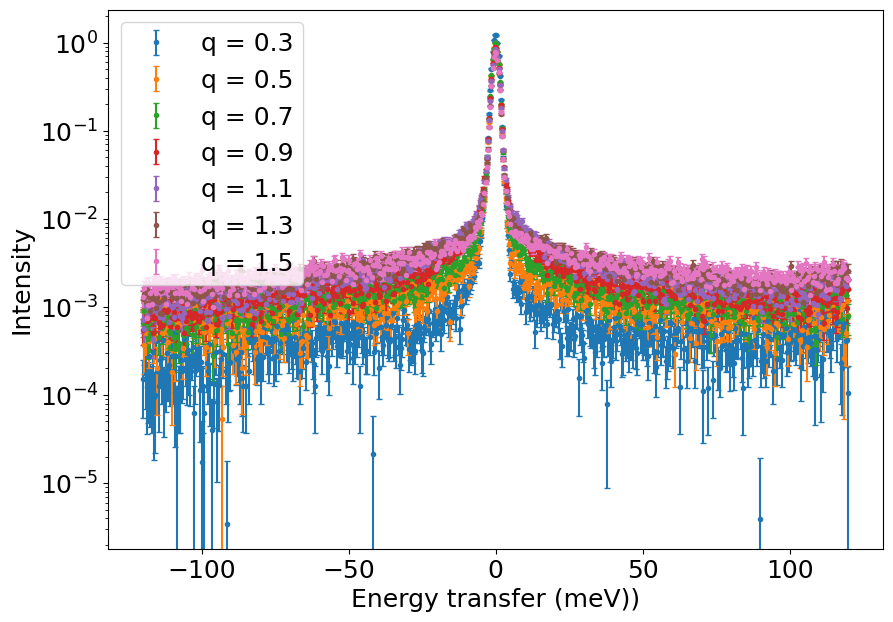

In [6]:
# data_300 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Hydrated/QENS/BSS_213056_divided_sqw.dat')
# data_250 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Hydrated/QENS/BSS_213060_divided_sqw.dat')
# data_200 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Hydrated/QENS/BSS_213064_divided_sqw.dat')
# data_175 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Hydrated/QENS/BSS_213069_divided_sqw.dat')
# data_225 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Hydrated/QENS/BSS_213075_divided_sqw.dat')
# data_275 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Hydrated/QENS/BSS_213079_divided_sqw.dat')
# data_50 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Hydrated/QENS/BSS_212917_divided_sqw.dat')

data_300 = extract_qens_data('../Data/ORNL/SOD_data/hyd_6.5/BASIS_213056_divided.dat')
data_250 = extract_qens_data('../Data/ORNL/SOD_data/hyd_6.5/BASIS_213060_divided.dat')
data_200 = extract_qens_data('../Data/ORNL/SOD_data/hyd_6.5/BASIS_213064_divided.dat')
data_175 = extract_qens_data('../Data/ORNL/SOD_data/hyd_6.5/BASIS_213068_divided.dat')
data_225 = extract_qens_data('../Data/ORNL/SOD_data/hyd_6.5/BASIS_213075_divided.dat')
data_275 = extract_qens_data('../Data/ORNL/SOD_data/hyd_6.5/BASIS_213079_divided.dat')
data_50 = extract_qens_data('../Data/ORNL/SOD_data/hyd_6.5/BASIS_212917_divided.dat')

all_data = [data_50, data_175, data_200, data_225, data_250, data_275, data_300]
q_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9]

plt.figure(figsize=(10,7))
for i in range(len(all_data)):
    d = all_data[i][4]
    q_index = q_values[i]
    plt.errorbar(
        d["energy"],
        d["intensity"],
        yerr=d["uncertainty"],
        fmt='o',
        markersize=3,
        capsize=2,
        label=f"q = {q_index}"
    )

plt.xlabel("Energy transfer (meV))")
plt.ylabel("Intensity")
#plt.title(f"QENS Spectrum (q index = {q_index})")
plt.yscale('log')
plt.legend()
plt.show()

In [11]:
all_data = [data_175, data_200, data_225, data_250, data_275, data_300]
Temps = [175, 200, 225, 250, 275, 300]
q = np.array([0.5, 0.7, 0.9, 1.1])
diffusion_coef_65 = []
tau_65 = []
diffusion_coef_err_65 = []
tau_err_65 = []
for j in range(len(all_data)):
    gamma_vals = []
    gamma_err = []
    for i in range(2, 6):
        q_index = i
        savedir = '6,5_CNT/QENS_fit_' + str(Temps[j]) + '_qindex_' +str(q_index) + '.png'
        popt, pcov = fit_and_plot_q_with_resolution(all_data[j], q_index, data_50[q_index]['energy'], data_50[q_index]['intensity'], savedir)
        gamma_vals.append(np.abs(popt[4]))
        gamma_err.append(np.sqrt(np.diag(pcov))[4])
        #print(q[q_index])
        print(q_index)
    # if j == 5:
    #     data_import = pd.read_csv('../Figures/6,5_CNT/diffusion_300_data.csv').values
    #     #q = data_import[:,0]
    #     gamma = data_import[:,1]
    #     gamma_err = data_import[:,2]
        
    gamma = np.array(gamma_vals)     # meV
    gamma_err = np.array(gamma_err)
    simple_result = fit_simple_diffusion(q, gamma)
    jump_result = fit_jump_diffusion(q, gamma, gamma_err)
    power_law_result = fit_power_law(q, gamma, gamma_err)
    q2_diffusion_result = fit_diffusion_q2(q, gamma, gamma_err)
    #plot_diffusion_fit(q, gamma, q2_diffusion_result)
    #plot_power_law_fit(q, gamma, power_law_result)
    print("(Simple) D =", simple_result["D"]*1e-4, "cm^2/s")
    print("(Jump) D =", jump_result["D"]*1e-4, "cm^2/s")
    print("tau =", jump_result["tau"], "ps")
    savedir = '6,5_CNT/diffusion_' + str(Temps[j]) + '.png'
    diffusion_coef_65.append(jump_result["D"]*1e-4)
    tau_65.append(jump_result["tau"])
    diffusion_coef_err_65.append(jump_result["D_err"]*1e-4)
    tau_err_65.append(jump_result["tau_err"])
    plot_diffusion_comparison(q, gamma, gamma_err, simple_result, jump_result, savedir)


Fit parameters (q=2):
Slope m = -5.8528e-08
Intercept b = 6.0968e-05
Elastic amplitude = 4.2548e+00
Quasielastic amplitude = 1.4491e-01
Gamma (HWHM) = 3.0783e+01
2

Fit parameters (q=3):
Slope m = -2.9076e-07
Intercept b = 2.3698e-04
Elastic amplitude = 2.9408e+00
Quasielastic amplitude = 1.2019e-01
Gamma (HWHM) = 3.2979e+01
3

Fit parameters (q=4):
Slope m = 3.8967e-07
Intercept b = 2.9861e-04
Elastic amplitude = 2.7112e+00
Quasielastic amplitude = 1.0321e-01
Gamma (HWHM) = 2.9627e+01
4

Fit parameters (q=5):
Slope m = 2.9520e-07
Intercept b = 2.9850e-04
Elastic amplitude = 2.9474e+00
Quasielastic amplitude = 8.4728e-02
Gamma (HWHM) = 2.7508e+01
5
(Simple) D = 5.089555770562417e-06 cm^2/s
(Jump) D = 4004.02861456856 cm^2/s
tau = 21.745820990132945 ps

Fit parameters (q=2):
Slope m = -5.0434e-08
Intercept b = 3.1325e-04
Elastic amplitude = 4.3548e+00
Quasielastic amplitude = 1.4548e-01
Gamma (HWHM) = 1.5676e+01
2

Fit parameters (q=3):
Slope m = -1.6144e-08
Intercept b = 5.2199e-04
El

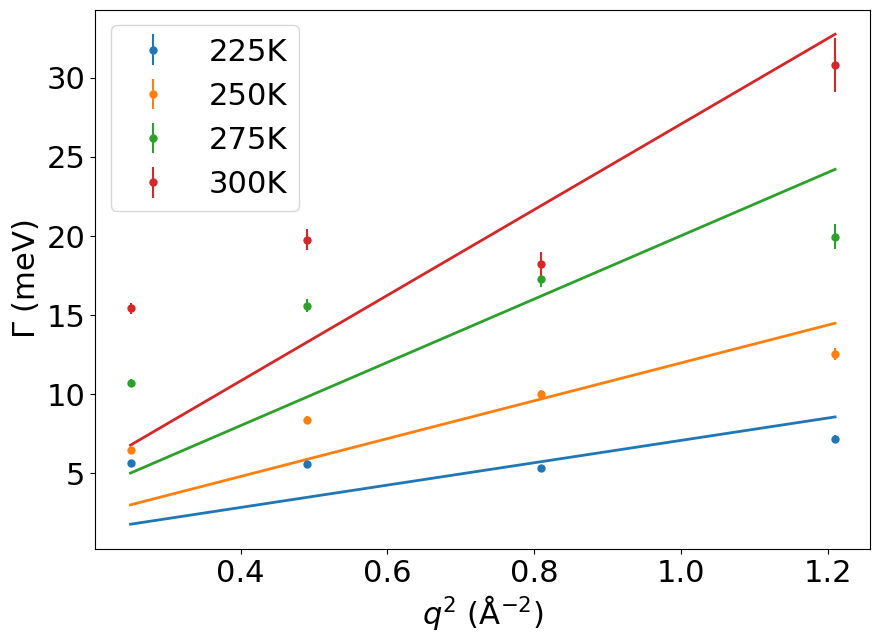

In [206]:
data_exp_200 = pd.read_csv('../Figures/6,5_CNT/diffusion_200_data.csv').values
data_fit_200 = pd.read_csv('../Figures/6,5_CNT/diffusion_200_fitted_data_simple.csv').values
data_exp_225 = pd.read_csv('../Figures/6,5_CNT/diffusion_225_data.csv').values
data_fit_225 = pd.read_csv('../Figures/6,5_CNT/diffusion_225_fitted_data_simple.csv').values
data_exp_250 = pd.read_csv('../Figures/6,5_CNT/diffusion_250_data.csv').values
data_fit_250 = pd.read_csv('../Figures/6,5_CNT/diffusion_250_fitted_data_simple.csv').values
data_exp_275 = pd.read_csv('../Figures/6,5_CNT/diffusion_275_data.csv').values
data_fit_275 = pd.read_csv('../Figures/6,5_CNT/diffusion_275_fitted_data_simple.csv').values
data_exp_300 = pd.read_csv('../Figures/6,5_CNT/diffusion_300_data.csv').values
data_fit_300 = pd.read_csv('../Figures/6,5_CNT/diffusion_300_fitted_data_simple.csv').values


plt.figure(figsize=(10,7))
# plt.scatter(data_exp_200[:,0], data_exp_200[:,1])
# plt.plot(data_fit_200[:,0], data_fit_200[:,1])
plt.errorbar(data_exp_225[:,0], data_exp_225[:,1], yerr=data_exp_225[:,2], fmt='o', markersize=5, label='225K', color ='C0')
plt.plot(data_fit_225[:,0], data_fit_225[:,1], linewidth=2)
plt.errorbar(data_exp_250[:,0], data_exp_250[:,1], yerr=data_exp_250[:,2], fmt='o', markersize=5, label='250K', color ='C1')
plt.plot(data_fit_250[:,0], data_fit_250[:,1], linewidth=2)
plt.errorbar(data_exp_275[:,0], data_exp_275[:,1], yerr=data_exp_275[:,2], fmt='o', markersize=5, label='275K', color ='C2')
plt.plot(data_fit_275[:,0], data_fit_275[:,1], linewidth=2)
plt.errorbar(data_exp_300[:,0], data_exp_300[:,1], yerr=data_exp_300[:,2], fmt='o', markersize=5, label='300K', color ='C3')
plt.plot(data_fit_300[:,0], data_fit_300[:,1], linewidth=2)
plt.xlabel(r"$q^2$ (Å$^{-2}$)")
plt.ylabel(r"$\Gamma$ (meV)")
plt.legend()
plt.savefig('../Figures/Simple_diffusion_65_CNT.png', dpi=600, bbox_inches="tight")


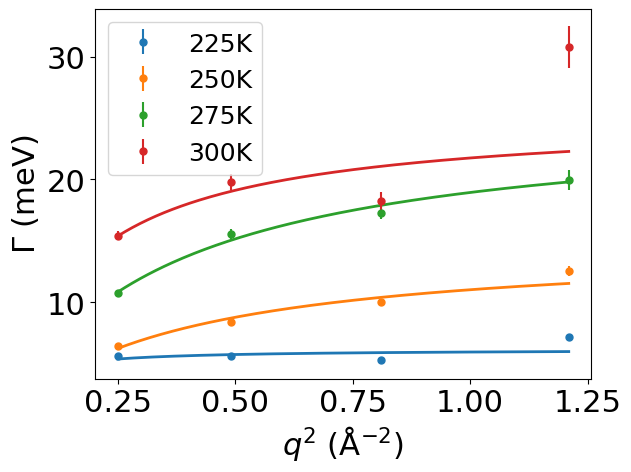

In [207]:
data_exp_200 = pd.read_csv('../Figures/6,5_CNT/diffusion_200_data.csv').values
data_fit_200 = pd.read_csv('../Figures/6,5_CNT/diffusion_200_fitted_data_jump.csv').values
data_exp_225 = pd.read_csv('../Figures/6,5_CNT/diffusion_225_data.csv').values
data_fit_225 = pd.read_csv('../Figures/6,5_CNT/diffusion_225_fitted_data_jump.csv').values
data_exp_250 = pd.read_csv('../Figures/6,5_CNT/diffusion_250_data.csv').values
data_fit_250 = pd.read_csv('../Figures/6,5_CNT/diffusion_250_fitted_data_jump.csv').values
data_exp_275 = pd.read_csv('../Figures/6,5_CNT/diffusion_275_data.csv').values
data_fit_275 = pd.read_csv('../Figures/6,5_CNT/diffusion_275_fitted_data_jump.csv').values
data_exp_300 = pd.read_csv('../Figures/6,5_CNT/diffusion_300_data.csv').values
data_fit_300 = pd.read_csv('../Figures/6,5_CNT/diffusion_300_fitted_data_jump.csv').values

plt.rcParams.update({'font.size': 22})
#plt.figure(figsize=(10,7))
# plt.scatter(data_exp_200[:,0], data_exp_200[:,1])
# plt.plot(data_fit_200[:,0], data_fit_200[:,1])
plt.errorbar(data_exp_225[:,0], data_exp_225[:,1], yerr=data_exp_225[:,2], fmt='o', markersize=5, label='225K', color ='C0')
plt.plot(data_fit_225[:,0], data_fit_225[:,1], linewidth=2)
plt.errorbar(data_exp_250[:,0], data_exp_250[:,1], yerr=data_exp_250[:,2], fmt='o', markersize=5, label='250K', color ='C1')
plt.plot(data_fit_250[:,0], data_fit_250[:,1], linewidth=2)
plt.errorbar(data_exp_275[:,0], data_exp_275[:,1], yerr=data_exp_275[:,2], fmt='o', markersize=5, label='275K', color ='C2')
plt.plot(data_fit_275[:,0], data_fit_275[:,1], linewidth=2)
plt.errorbar(data_exp_300[:,0], data_exp_300[:,1], yerr=data_exp_300[:,2], fmt='o', markersize=5, label='300K', color ='C3')
plt.plot(data_fit_300[:,0], data_fit_300[:,1], linewidth=2)
plt.xlabel(r"$q^2$ (Å$^{-2}$)")
plt.ylabel(r"$\Gamma$ (meV)")
plt.legend(fontsize=18)
plt.savefig('../Figures/Jump_diffusion_65_CNT.png', dpi=600, bbox_inches="tight")


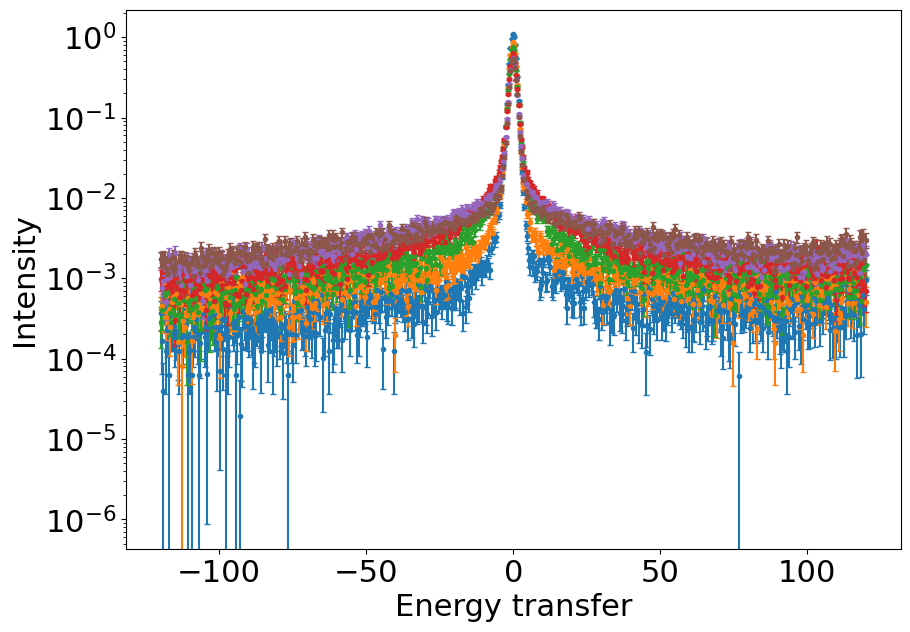

In [208]:
# data_50 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/0.84 CNT Hydrated/QENS/BSS_213198_divided_sqw.dat')
# data_300 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/0.84 CNT Hydrated/QENS/BSS_213328_divided_sqw.dat')
# data_275 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/0.84 CNT Hydrated/QENS/BSS_213331_divided_sqw.dat')
# data_250 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/0.84 CNT Hydrated/QENS/BSS_213334_divided_sqw.dat')
# data_225 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/0.84 CNT Hydrated/QENS/BSS_213337_divided_sqw.dat')
# data_200 = load_qens_csv_blocks('../Data/ORNL/Processed_Data/0.84 CNT Hydrated/QENS/BSS_213340_divided_sqw.dat')


data_50 = extract_qens_data('../Data/ORNL/SOD_data/hyd_0.84/BASIS_213198_divided.dat')
data_300 = extract_qens_data('../Data/ORNL/SOD_data/hyd_0.84/BASIS_213328_divided.dat')
data_275 = extract_qens_data('../Data/ORNL/SOD_data/hyd_0.84/BASIS_213331_divided.dat')
data_250 = extract_qens_data('../Data/ORNL/SOD_data/hyd_0.84/BASIS_213334_divided.dat')
data_225 = extract_qens_data('../Data/ORNL/SOD_data/hyd_0.84/BASIS_213337_divided.dat')
data_200 = extract_qens_data('../Data/ORNL/SOD_data/hyd_0.84/BASIS_213340_divided.dat')


all_data = [data_50, data_200, data_225, data_250, data_275, data_300]
q_values = [0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9]

plt.figure(figsize=(10,7))
for i in range(len(all_data)):
    d = all_data[i][4]
    q_index = q_values[i]
    plt.errorbar(
        d["energy"],
        d["intensity"],
        yerr=d["uncertainty"],
        fmt='o',
        markersize=3,
        capsize=2,
        label=f"q = {q_index}"
    )

plt.xlabel("Energy transfer")
plt.ylabel("Intensity")
#plt.title(f"QENS Spectrum (q index = {q_index})")
plt.yscale('log')
#plt.legend()
plt.show()

In [209]:
all_data = [data_200, data_225, data_250, data_275, data_300]
Temps = [200, 225, 250, 275, 300]
q = np.array([0.5, 0.7, 0.9, 1.1])
diffusion_coef_80 = []
diffusion_coef_err_80 = []
tau_80 = []
tau_err_80 = []
for j in range(len(all_data)):
    gamma_vals = []
    gamma_err = []
    for i in range(2, 6):
        q_index = i
        savedir = '0.8_CNT/QENS_fit_' + str(Temps[j]) + '_qindex_' +str(q_index) + '.png'
        popt, pcov = fit_and_plot_q_with_resolution(all_data[j], q_index, data_50[q_index]['energy'], data_50[q_index]['intensity'], savedir)
        gamma_vals.append(np.abs(popt[4]))
        gamma_err.append(np.sqrt(np.diag(pcov))[4])
    gamma = np.array(gamma_vals)     # meV
    gamma_err = np.array(gamma_err)
    simple_result = fit_simple_diffusion(q, gamma)
    jump_result = fit_jump_diffusion(q, gamma, gamma_err)
    #power_law_result = fit_power_law(q, gamma, gamma_err)
    #plot_power_law_fit(q, gamma, power_law_result)
    #print("(Simple) D =", simple_result["D"]*1e-4, "cm^2/s")
    print("(Jump) D =", jump_result["D"]*1e-4, "cm^2/s")
    print("tau =", jump_result["tau"], "ps")
    savedir = '0.8_CNT/diffusion_' + str(Temps[j]) + '.png'
    diffusion_coef_80.append(jump_result["D"]*1e-4)
    diffusion_coef_err_80.append(jump_result["D_err"]*1e-4)
    tau_80.append(jump_result["tau"])
    tau_err_80.append(jump_result["tau_err"])
    plot_diffusion_comparison(q, gamma, gamma_err, simple_result, jump_result, savedir)



Fit parameters (q=2):
Slope m = 4.9388e-07
Intercept b = 1.9198e-04
Elastic amplitude = 3.3563e+00
Quasielastic amplitude = 7.3501e-02
Gamma (HWHM) = 7.9714e+00

Fit parameters (q=3):
Slope m = 1.0000e-08
Intercept b = 1.0000e-04
Elastic amplitude = 5.0000e-03
Quasielastic amplitude = 1.4000e-04
Gamma (HWHM) = 2.9000e-02

Fit parameters (q=4):
Slope m = 1.5962e-07
Intercept b = 3.2923e-04
Elastic amplitude = 2.2809e+00
Quasielastic amplitude = 1.2632e-01
Gamma (HWHM) = 3.8251e+00

Fit parameters (q=5):
Slope m = 6.4370e-07
Intercept b = 3.1178e-04
Elastic amplitude = 1.9338e+00
Quasielastic amplitude = 1.9614e-01
Gamma (HWHM) = 1.8983e+00
(Jump) D = 31.809272094683596 cm^2/s
tau = 245.96970683747296 ps

Fit parameters (q=2):
Slope m = 3.7824e-07
Intercept b = 3.1175e-04
Elastic amplitude = 3.1164e+00
Quasielastic amplitude = 2.6861e-01
Gamma (HWHM) = 3.3031e+00

Fit parameters (q=3):
Slope m = 2.4649e-08
Intercept b = 3.9173e-04
Elastic amplitude = 2.3395e+00
Quasielastic amplitude = 

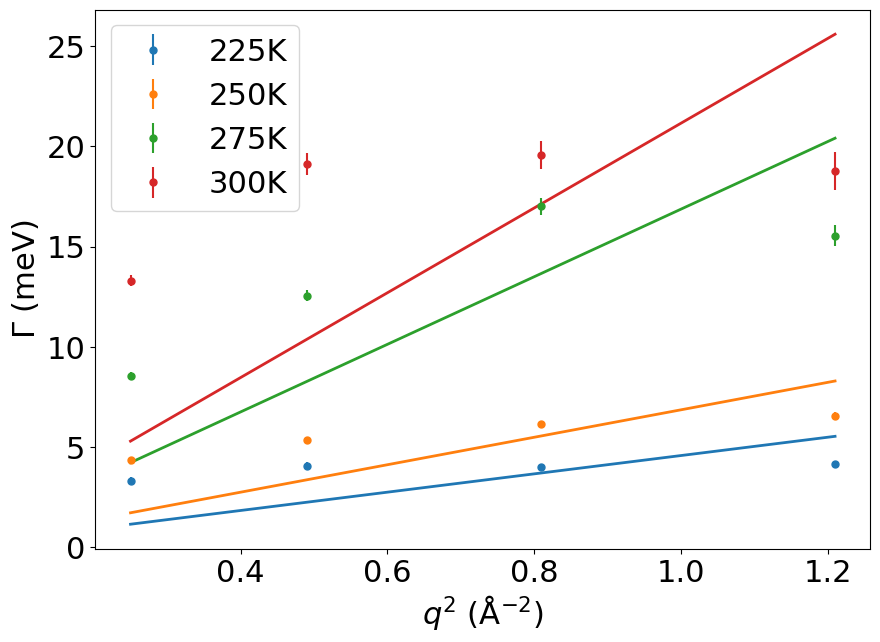

In [210]:
data_exp_200 = pd.read_csv('../Figures/0.8_CNT/diffusion_200_data.csv').values
data_fit_200 = pd.read_csv('../Figures/0.8_CNT/diffusion_200_fitted_data_simple.csv').values
data_exp_225 = pd.read_csv('../Figures/0.8_CNT/diffusion_225_data.csv').values
data_fit_225 = pd.read_csv('../Figures/0.8_CNT/diffusion_225_fitted_data_simple.csv').values
data_exp_250 = pd.read_csv('../Figures/0.8_CNT/diffusion_250_data.csv').values
data_fit_250 = pd.read_csv('../Figures/0.8_CNT/diffusion_250_fitted_data_simple.csv').values
data_exp_275 = pd.read_csv('../Figures/0.8_CNT/diffusion_275_data.csv').values
data_fit_275 = pd.read_csv('../Figures/0.8_CNT/diffusion_275_fitted_data_simple.csv').values
data_exp_300 = pd.read_csv('../Figures/0.8_CNT/diffusion_300_data.csv').values
data_fit_300 = pd.read_csv('../Figures/0.8_CNT/diffusion_300_fitted_data_simple.csv').values
plt.figure(figsize=(10,7))
# plt.scatter(data_exp_200[:,0], data_exp_200[:,1])
# plt.plot(data_fit_200[:,0], data_fit_200[:,1])
plt.errorbar(data_exp_225[:,0], data_exp_225[:,1], yerr=data_exp_225[:,2], fmt='o', markersize=5, label='225K', color ='C0')
plt.plot(data_fit_225[:,0], data_fit_225[:,1], linewidth=2)
plt.errorbar(data_exp_250[:,0], data_exp_250[:,1], yerr=data_exp_250[:,2], fmt='o', markersize=5, label='250K', color ='C1')
plt.plot(data_fit_250[:,0], data_fit_250[:,1], linewidth=2)
plt.errorbar(data_exp_275[:,0], data_exp_275[:,1], yerr=data_exp_275[:,2], fmt='o', markersize=5, label='275K', color ='C2')
plt.plot(data_fit_275[:,0], data_fit_275[:,1], linewidth=2)
plt.errorbar(data_exp_300[:,0], data_exp_300[:,1], yerr=data_exp_300[:,2], fmt='o', markersize=5, label='300K', color ='C3')
plt.plot(data_fit_300[:,0], data_fit_300[:,1], linewidth=2)
plt.xlabel(r"$q^2$ (Å$^{-2}$)")
plt.ylabel(r"$\Gamma$ (meV)")
plt.legend()
plt.savefig('../Figures/Simple_diffusion_66_CNT.png', dpi=600, bbox_inches="tight")

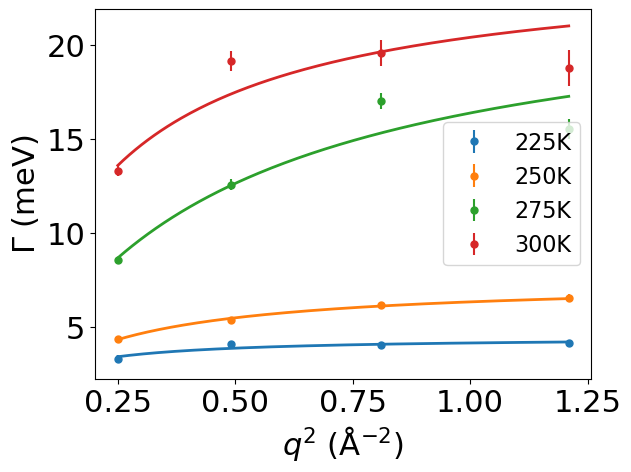

In [211]:
data_exp_200 = pd.read_csv('../Figures/0.8_CNT/diffusion_200_data.csv').values
data_fit_200 = pd.read_csv('../Figures/0.8_CNT/diffusion_200_fitted_data_jump.csv').values
data_exp_225 = pd.read_csv('../Figures/0.8_CNT/diffusion_225_data.csv').values
data_fit_225 = pd.read_csv('../Figures/0.8_CNT/diffusion_225_fitted_data_jump.csv').values
data_exp_250 = pd.read_csv('../Figures/0.8_CNT/diffusion_250_data.csv').values
data_fit_250 = pd.read_csv('../Figures/0.8_CNT/diffusion_250_fitted_data_jump.csv').values
data_exp_275 = pd.read_csv('../Figures/0.8_CNT/diffusion_275_data.csv').values
data_fit_275 = pd.read_csv('../Figures/0.8_CNT/diffusion_275_fitted_data_jump.csv').values
data_exp_300 = pd.read_csv('../Figures/0.8_CNT/diffusion_300_data.csv').values
data_fit_300 = pd.read_csv('../Figures/0.8_CNT/diffusion_300_fitted_data_jump.csv').values
#plt.figure(figsize=(10,7))
plt.rcParams.update({'font.size': 22})
# plt.scatter(data_exp_200[:,0], data_exp_200[:,1])
# plt.plot(data_fit_200[:,0], data_fit_200[:,1])
plt.errorbar(data_exp_225[:,0], data_exp_225[:,1], yerr=data_exp_225[:,2], fmt='o', markersize=5, label='225K', color ='C0')
plt.plot(data_fit_225[:,0], data_fit_225[:,1], linewidth=2)
plt.errorbar(data_exp_250[:,0], data_exp_250[:,1], yerr=data_exp_250[:,2], fmt='o', markersize=5, label='250K', color ='C1')
plt.plot(data_fit_250[:,0], data_fit_250[:,1], linewidth=2)
plt.errorbar(data_exp_275[:,0], data_exp_275[:,1], yerr=data_exp_275[:,2], fmt='o', markersize=5, label='275K', color ='C2')
plt.plot(data_fit_275[:,0], data_fit_275[:,1], linewidth=2)
plt.errorbar(data_exp_300[:,0], data_exp_300[:,1], yerr=data_exp_300[:,2], fmt='o', markersize=5, label='300K', color ='C3')
plt.plot(data_fit_300[:,0], data_fit_300[:,1], linewidth=2)
plt.xlabel(r"$q^2$ (Å$^{-2}$)")
plt.ylabel(r"$\Gamma$ (meV)")
plt.legend(fontsize=16)
plt.savefig('../Figures/Jump_diffusion_66_CNT.png', dpi=600, bbox_inches="tight")

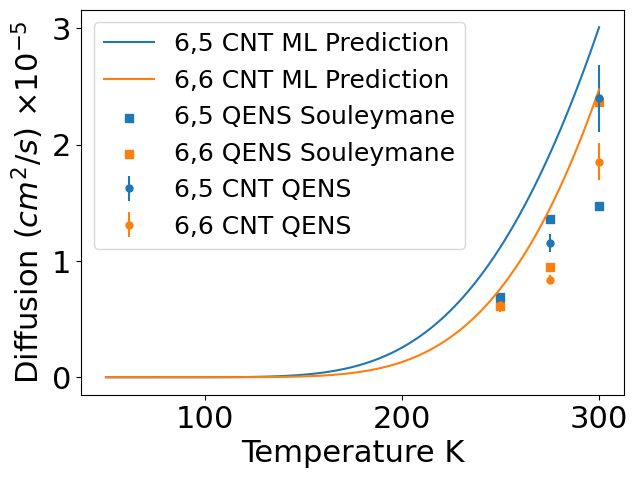

In [20]:
data_coef_200_65 = pd.read_csv('../Figures/6,5_CNT/diffusion_200_fitted_coef_jump.csv').values
data_coef_225_65 = pd.read_csv('../Figures/6,5_CNT/diffusion_225_fitted_coef_jump.csv').values
data_coef_250_65 = pd.read_csv('../Figures/6,5_CNT/diffusion_250_fitted_coef_jump.csv').values
data_coef_275_65 = pd.read_csv('../Figures/6,5_CNT/diffusion_275_fitted_coef_jump.csv').values
data_coef_300_65 = pd.read_csv('../Figures/6,5_CNT/diffusion_300_fitted_coef_jump.csv').values
diff_65 = [data_coef_200_65[0][0], data_coef_225_65[0][0], data_coef_250_65[0][0], data_coef_275_65[0][0], data_coef_300_65[0][0]]
diff_err_65 = [data_coef_200_65[0][2], data_coef_225_65[0][2], data_coef_250_65[0][2], data_coef_275_65[0][2], data_coef_300_65[0][2]]
tau_65 = [data_coef_200_65[0][1], data_coef_225_65[0][1], data_coef_250_65[0][1], data_coef_275_65[0][1], data_coef_300_65[0][1]]
tau_err_65 = [data_coef_200_65[0][3], data_coef_225_65[0][3], data_coef_250_65[0][3], data_coef_275_65[0][3], data_coef_300_65[0][3]]

data_coef_200_80 = pd.read_csv('../Figures/0.8_CNT/diffusion_200_fitted_coef_jump.csv').values
data_coef_225_80 = pd.read_csv('../Figures/0.8_CNT/diffusion_225_fitted_coef_jump.csv').values
data_coef_250_80 = pd.read_csv('../Figures/0.8_CNT/diffusion_250_fitted_coef_jump.csv').values
data_coef_275_80 = pd.read_csv('../Figures/0.8_CNT/diffusion_275_fitted_coef_jump.csv').values
data_coef_300_80 = pd.read_csv('../Figures/0.8_CNT/diffusion_300_fitted_coef_jump.csv').values

diff_80 = [data_coef_200_80[0][0], data_coef_225_80[0][0], data_coef_250_80[0][0], data_coef_275_80[0][0], data_coef_300_80[0][0]]
diff_err_80 = [data_coef_200_80[0][2], data_coef_225_80[0][2], data_coef_250_80[0][2], data_coef_275_80[0][2], data_coef_300_80[0][2]]
tau_80 = [data_coef_200_80[0][1], data_coef_225_80[0][1], data_coef_250_80[0][1], data_coef_275_80[0][1], data_coef_300_80[0][1]]
tau_err_80 = [data_coef_200_80[0][3], data_coef_225_80[0][3], data_coef_250_80[0][3], data_coef_275_80[0][3], data_coef_300_80[0][3]]

Temps = [200, 225, 250, 275, 300]
fig, ax = plt.subplots(figsize=(7, 5))

plt.errorbar(Temps[2:], np.array(diff_65[2:])*1e5, yerr=np.array(diff_err_65[2:])*1e5, fmt='o', markersize=5, label='6,5 CNT QENS', color ='C0')
plt.errorbar(Temps[2:], np.array(diff_80[2:])*1e5, yerr=np.array(diff_err_80[2:])*1e5, fmt='o', markersize=5, label='6,6 CNT QENS', color ='C1')

def arrhenius(T, A, Ea):
    R = 8.314
    return A * np.exp(-Ea / (R * T))

T = np.linspace(50, Temps[-1], 100)
CNT_65_pred = arrhenius(T, 0.004221, 12330)
CNT_66_pred = arrhenius(T, 0.008908, 14680)
#CNT_65_pred = arrhenius(T, 0.0059, 13411)
#CNT_66_pred = arrhenius(T, 0.0154, 15179)


#plt.rcParams.update({'font.size': 22})

plt.plot(T, CNT_65_pred*1e5, label='6,5 CNT ML Prediction')
plt.plot(T, CNT_66_pred*1e5, label='6,6 CNT ML Prediction')



Souleymane_65D = np.array([6.9237e-6, 13.5731e-6, 14.6812e-6])
Souleymane_66D = np.array([6.12e-6, 9.462e-6, 23.66e-6])
plt.scatter(Temps[2:], Souleymane_65D*1e5, label='6,5 QENS Souleymane', color = 'C0', marker='s')
plt.scatter(Temps[2:], Souleymane_66D*1e5, label='6,6 QENS Souleymane', color = 'C1', marker='s')


# data_65 = np.hstack((np.array(Temps[2:]).reshape(-1,1), np.array(diff_65[2:]).reshape(-1,1), np.array(diff_err_65[2:]).reshape(-1,1)))
# data_66 = np.hstack((np.array(Temps[2:]).reshape(-1,1), np.array(diff_80[2:]).reshape(-1,1), np.array(diff_err_80[2:]).reshape(-1,1)))
# np.savetxt('QENS_Jump_diffusion_65.txt', data_65)
# np.savetxt('QENS_Jump_diffusion_66.txt', data_66)

y1 = [0.3e-5]*len(T)
y2 = [3e-5]*len(T)
#plt.fill_between(T, y1, y2, color='gray', alpha=0.4)


plt.xlabel('Temperature K')
plt.ylabel('Diffusion ($cm^{2}/s$) $\\times 10^{-5}$')
#plt.ylabel('Diffusion ($cm^{2}/s$)') #$\\times 10^{-5}$')
plt.legend(loc='upper left', fontsize=18)
plt.savefig('../Figures/Diffusion_exp_sim.png', dpi=600, bbox_inches="tight")

Fit result for 6,5 CNT with Ea fixed
  tau0 = 0.127 ± 0.00354  ps
  Ea   = 12.330 eV (fixed)
Fit result for 6,6 CNT with Ea fixed
  tau0 = 0.169 ± 0.00397  ps
  Ea   = 14.680 eV (fixed)


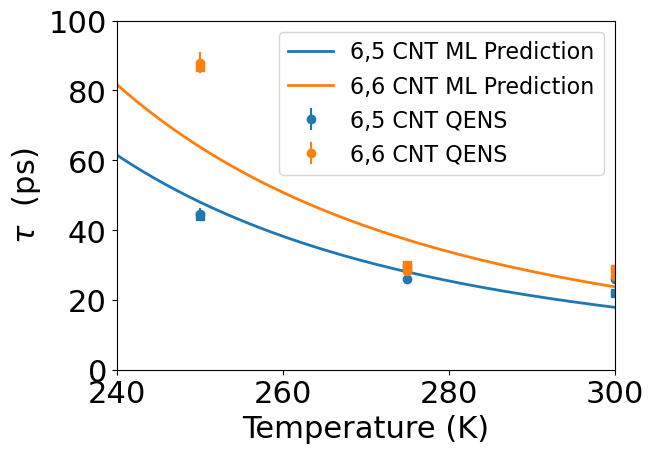

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------------------------------------------------
# 1)  DATA  -------------------------------------------------------------
# (replace tau_65 and tau_err_65 by your actual arrays)
Temps       = np.array([200, 225, 250, 275, 300])   # K
x_value     = Temps[2:]                             # 225–300 K
y_value_65  = tau_65[2:]                            # τ (ps) for 6,5 CNT
yerr_65     = tau_err_65[2:]
y_value_80  = tau_80[2:]                        # ±1σ errors (ps)
yerr_80 = tau_err_80[2:]

# ----------------------------------------------------------------------
# 2)  CONSTANT ACTIVATION ENERGY (set this to the value you want) ------
Ea_meV_fixed = 12330           # <---- put your chosen Ea in meV here
kB_meV       = 8.314     # Boltzmann constant in meV / K
B_fixed      =  Ea_meV_fixed / kB_meV   # = Ea / kB  (dimensionless)

# ----------------------------------------------------------------------
# 3)  ARRHENIUS MODEL WITH FIXED Ea ------------------------------------
def arrhenius_fixed_Ea(T, tau0):
    """
    Arrhenius expression with *fixed* activation energy:

        τ(T) = τ0 · exp(Ea / (k_B T))      (τ0 in ps, Ea fixed)

    Parameters
    ----------
    T     : temperature in K (scalar or array)
    tau0  : pre-exponential factor to be fitted (ps)
    """
    return tau0 * np.exp(B_fixed / T)

# Initial guess for τ0: use first data point scaled down a bit
tau0_guess = y_value_65[0] * np.exp(-B_fixed / x_value[0])

# ----------------------------------------------------------------------
# 4)  Fit τ0, keep Ea fixed -------------------------------------------
popt, pcov = curve_fit(arrhenius_fixed_Ea, x_value, y_value_65,
                       p0=[tau0_guess],
                       sigma=yerr_65,
                       absolute_sigma=True,  # treat σ as absolute
                       maxfev=10000)

tau0_fit = popt[0]
tau0_err = np.sqrt(pcov[0, 0])

print("Fit result for 6,5 CNT with Ea fixed")
print(f"  tau0 = {tau0_fit:.3g} ± {tau0_err:.3g}  ps")
print(f"  Ea   = {Ea_meV_fixed/1000:.3f} eV (fixed)")

# ----------------------------------------------------------------------
# 5)  Plot --------------------------------------------------------------
T_smooth = np.linspace(Temps.min(), Temps.max(), 300)
#tau0_fit = 0.1428
tau_pred = arrhenius_fixed_Ea(T_smooth, tau0_fit)

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(x_value, y_value_65, yerr=yerr_65,
            fmt='o', color='C0', label='6,5 CNT QENS')
ax.plot(T_smooth, tau_pred, color='C0', lw=2,
        label='6,5 CNT ML Prediction')

# data_pred_66 = np.column_stack((T_smooth, tau_pred))
# np.savetxt(
#     'MD_ML_pred_Tau_65.txt',
#     data_pred_66,
#     header='Temperature(K)\ttau_pred(ps)',
#     delimiter='\t',
#     comments=''
# )

data_65_tau = np.hstack((np.array(T_smooth).reshape(-1,1), np.array(tau_pred).reshape(-1,1)))

popt, pcov = curve_fit(arrhenius_fixed_Ea, x_value, y_value_80,
                       p0=[tau0_guess],
                       sigma=yerr_80,
                       absolute_sigma=True,  # treat σ as absolute
                       maxfev=10000)

tau0_fit = popt[0]
tau0_err = np.sqrt(pcov[0, 0])

print("Fit result for 6,6 CNT with Ea fixed")
Ea_meV_fixed = 14680
print(f"  tau0 = {tau0_fit:.3g} ± {tau0_err:.3g}  ps")
print(f"  Ea   = {Ea_meV_fixed/1000:.3f} eV (fixed)")

# ----------------------------------------------------------------------
# 5)  Plot --------------------------------------------------------------
T_smooth = np.linspace(Temps.min(), Temps.max(), 300)
#tau0_fit = 0.1428
tau_pred = arrhenius_fixed_Ea(T_smooth, tau0_fit)
ax.errorbar(x_value, y_value_80, yerr=yerr_80,
            fmt='o', color='C1', label='6,6 CNT QENS')

ax.plot(T_smooth, tau_pred, color='C1', lw=2,
        label='6,6 CNT ML Prediction')

# data_pred_66 = np.column_stack((T_smooth, tau_pred))
# np.savetxt(
#     'MD_ML_pred_Tau_66.txt',
#     data_pred_66,
#     header='Temperature(K)\ttau_pred(ps)',
#     delimiter='\t',
#     comments=''
# )

souleymane_tau_65 = np.array([0.44, 0.29, 0.22])*100
souleymane_tau_66 = np.array([0.865528, 0.300, 0.289])*100
plt.scatter(x_value, souleymane_tau_65, color='C0', marker='s')
plt.scatter(x_value, souleymane_tau_66, color='C1', marker='s')


# data_66_tau = np.hstack((np.array(T_smooth).reshape(-1,1), np.array(tau_pred).reshape(-1,1)))
# data_65 = np.hstack((np.array(x_value).reshape(-1,1), np.array(y_value_65).reshape(-1,1), np.array(y_value_65).reshape(-1,1)))
# data_66 = np.hstack((np.array(x_value).reshape(-1,1), np.array(y_value_80).reshape(-1,1), np.array(yerr_80).reshape(-1,1)))
# np.savetxt('QENS_Tau_65.txt', data_65)
# np.savetxt('QENS_Tau_66.txt', data_66)
# np.savetxt('MD_ML_pred_Tau_65.txt', data_65_tau)
# np.savetxt('MD_ML_pred_Tau_66.txt', data_66_tau)

ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$\tau$  (ps)')
#ax.set_yscale('log')           # usually helpful for Arrhenius plots
ax.set_xlim(240, 300)
ax.set_ylim(0, 100)
ax.legend(fontsize=16)
plt.tight_layout()
#plt.savefig('../Figures/tau_fit_fixedEa.png', dpi=600, bbox_inches='tight')
plt.show()

In [214]:
q = np.array([0.5, 0.7, 0.9, 1.1])
gamma = np.array([0.01476, 0.01837, 0.01727, 0.02687])
gamma_err = np.array([0.000372, 0.000648, 0.000768, 0.001693])
jump_result = fit_jump_diffusion(q, gamma, gamma_err)
jump_result

{'D': np.float64(0.0002572781461555612),
 'tau': np.float64(29054.266083145354),
 'D_err': np.float64(3.711586419719897e-05),
 'tau_err': np.float64(1565.116846277593),
 'cov': array([[1.37758738e-09, 5.19537184e-02],
        [5.19537184e-02, 2.44959074e+06]])}

In [215]:
q = np.array([0.5, 0.7, 0.9, 1.1])
gamma = np.array([0.0154, 0.0197, 0.01821, 0.03078])
gamma_err = np.array([0.000372, 0.000648, 0.000768, 0.001693])
jump_result = fit_jump_diffusion(q, gamma, gamma_err)
jump_result

{'D': np.float64(0.0002401956582395549),
 'tau': np.float64(26141.254376735928),
 'D_err': np.float64(2.881119943336825e-05),
 'tau_err': np.float64(1354.090524126066),
 'cov': array([[8.30085213e-10, 3.47037276e-02],
        [3.47037276e-02, 1.83356115e+06]])}

In [216]:
HBAR = 0.658 #meV*ps
q = np.array([0.5, 0.7, 0.9, 1.1])
Souleymane_65D = np.array([6.9237e-6, 13.5731e-6, 14.6812e-6])*1e4 #units of angstrom2/ps
Souleymane_66D = np.array([6.12e-6, 9.462e-6, 23.66e-6])*1e4 #units of angstrom2/ps
souleymane_tau_65 = np.array([0.44, 0.29, 0.22])
souleymane_tau_66 = np.array([0.865528, 0.300, 0.289])
temps = [250, 275, 300]
gamma_65_lst = []
gamma_66_lst = []
i = 0
gamma_65_250 = jump_diffusion_model(q, Souleymane_65D[i], souleymane_tau_65[i])*HBAR
gamma_66_250 = jump_diffusion_model(q, Souleymane_66D[i], souleymane_tau_66[i])*HBAR

i = 1
gamma_65_275 = jump_diffusion_model(q, Souleymane_65D[i], souleymane_tau_65[i])*HBAR
gamma_66_275 = jump_diffusion_model(q, Souleymane_66D[i], souleymane_tau_66[i])*HBAR

i = 2
gamma_65_300 = jump_diffusion_model(q, Souleymane_65D[i], souleymane_tau_65[i])*HBAR
gamma_66_300 = jump_diffusion_model(q, Souleymane_66D[i], souleymane_tau_66[i])*HBAR

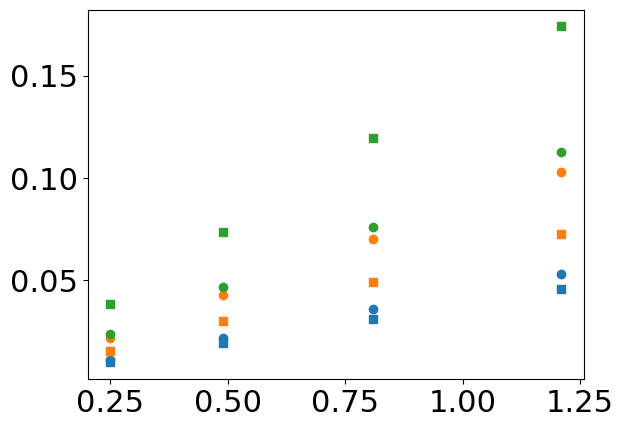

In [200]:
plt.scatter(q**2, gamma_65_250, color='C0')
plt.scatter(q**2, gamma_65_275, color='C1')
plt.scatter(q**2, gamma_65_300, color='C2')

plt.scatter(q**2, gamma_66_250, color='C0', marker='s')
plt.scatter(q**2, gamma_66_275, color='C1', marker='s')
plt.scatter(q**2, gamma_66_300, color='C2', marker='s')



In [201]:
q = np.array([0.5, 0.7, 0.9, 1.1])
diffusion_huat_65 = np.array(diff_65[2:])*1e4 #unitsa of angstrom2/ps
diffusion_huat_66 = np.array(diff_80[2:])*1e4 #unitsa of angstrom2/ps
tau_huat_65 = y_value_65
tau_huat_80 = y_value_80
temps = [250, 275, 300]
gamma_65_lst = []
gamma_66_lst = []

i = 0
gamma_65_250_huat = jump_diffusion_model(q, diffusion_huat_65[i], tau_huat_65[i])*HBAR
gamma_66_250_huat = jump_diffusion_model(q, diffusion_huat_66[i], tau_huat_80[i])*HBAR

i = 1
gamma_65_275_huat = jump_diffusion_model(q, diffusion_huat_65[i], tau_huat_65[i])*HBAR
gamma_66_275_huat = jump_diffusion_model(q, diffusion_huat_66[i], tau_huat_80[i])*HBAR

i = 2
gamma_65_300_huat = jump_diffusion_model(q, diffusion_huat_65[i], tau_huat_65[i])*HBAR
gamma_66_300_huat = jump_diffusion_model(q, diffusion_huat_66[i], tau_huat_80[i])*HBAR

Text(0.5, 0, '$q^{2}$ $(\\AA^{2})$')

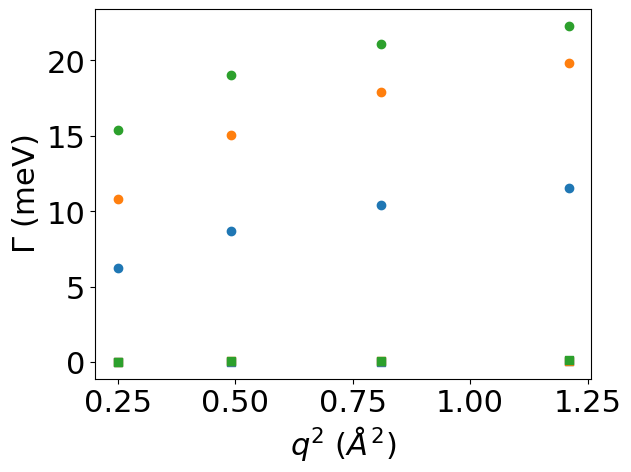

In [202]:
plt.scatter(q**2, gamma_65_250_huat, color = 'C0')
plt.scatter(q**2, gamma_65_275_huat, color = 'C1')
plt.scatter(q**2, gamma_65_300_huat, color = 'C2')

plt.scatter(q**2, gamma_65_250, color = 'C0', marker='s')
plt.scatter(q**2, gamma_65_275, color = 'C1', marker='s')
plt.scatter(q**2, gamma_65_300, color = 'C2', marker='s')

plt.ylabel(r"$\Gamma$ (meV)")
plt.xlabel('$q^{2}$ $(\\AA^{2})$' )

## Elastic Scan

plot individual q

Text(0, 0.5, 'EISF')

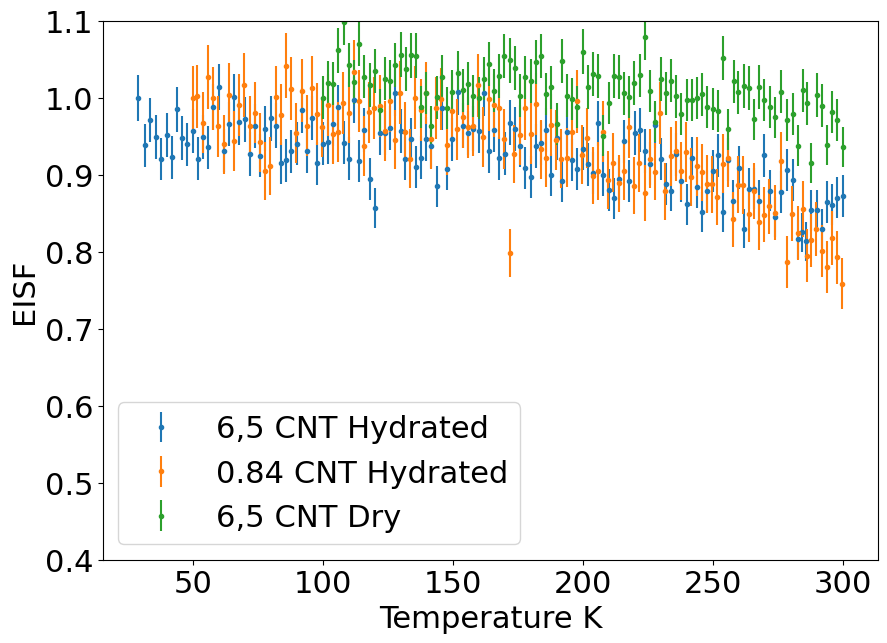

In [ ]:
plt.figure(figsize=(10,7))
plt.rcParams.update({'font.size': 22})
i = 1
elastic_scan = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Hydrated/Elastic Scan/BSS_212918_divided_sqw_elwin_elt.dat')
energy = elastic_scan[i]['energy']
intensity = elastic_scan[i]['intensity']
uncertainty = elastic_scan[i]['uncertainty']

plt.errorbar(
    energy, intensity,
    yerr=uncertainty,
    fmt='o', markersize=3,
    label='6,5 CNT Hydrated'
)


elastic_scan = load_qens_csv_blocks('../Data/ORNL/Processed_Data/0.84 CNT Hydrated/Elastic Scan/BSS_213202_divided_sqw_elwin_elt.dat')
energy = elastic_scan[i]['energy']
intensity = elastic_scan[i]['intensity']
uncertainty = elastic_scan[i]['uncertainty']

plt.errorbar(
    energy, intensity,
    yerr=uncertainty,
    fmt='o', markersize=3,
    label='0.84 CNT Hydrated'
)

elastic_scan = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Dry/Elastic Scan/BSS_213084_divided_sqw_elwin_elt.dat')
energy = elastic_scan[i]['energy']
intensity = elastic_scan[i]['intensity']
uncertainty = elastic_scan[i]['uncertainty']

plt.errorbar(
    energy, intensity,
    yerr=uncertainty,
    fmt='o', markersize=3,
    label='6,5 CNT Dry'
)

plt.legend()
plt.ylim([0.4,1.1])
plt.xlabel('Temperature K')
plt.ylabel('EISF')

plot average of all q

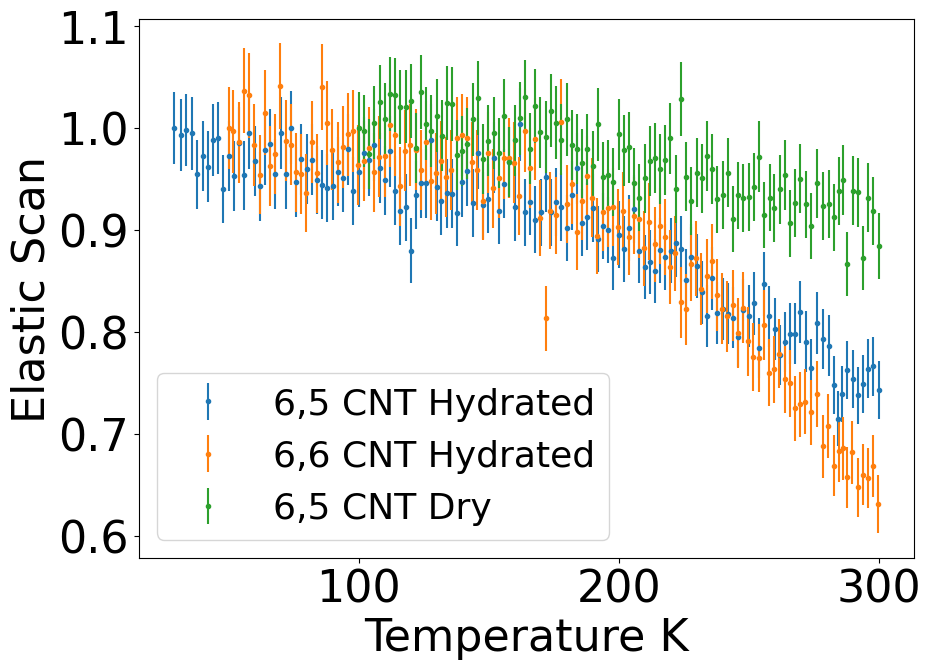

In [ ]:
plt.figure(figsize=(10,7))
plt.rcParams.update({'font.size': 32})
initial_q = 1
upper_q = 5
e_list = []
i_list = []
u_list = []
elastic_scan = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Hydrated/Elastic Scan/BSS_212918_divided_sqw_elwin_elt.dat')
for i in range(initial_q,upper_q):
    e_list.append(elastic_scan[i]['energy'])
    i_list.append(elastic_scan[i]['intensity'])
    u_list.append(elastic_scan[i]['uncertainty'])

energy = np.mean(np.array(e_list), axis=0)
intensity = np.mean(np.array(i_list), axis=0)
uncertainty = np.mean(np.array(u_list), axis=0)

plt.errorbar(
    energy, intensity,
    yerr=uncertainty,
    fmt='o', markersize=3,
    label='6,5 CNT Hydrated'
)


e_list = []
i_list = []
u_list = []
elastic_scan = load_qens_csv_blocks('../Data/ORNL/Processed_Data/0.84 CNT Hydrated/Elastic Scan/BSS_213202_divided_sqw_elwin_elt.dat')
for i in range(initial_q,upper_q):
    e_list.append(elastic_scan[i]['energy'])
    i_list.append(elastic_scan[i]['intensity'])
    u_list.append(elastic_scan[i]['uncertainty'])

energy = np.mean(np.array(e_list), axis=0)
intensity = np.mean(np.array(i_list), axis=0)
uncertainty = np.mean(np.array(u_list), axis=0)
plt.errorbar(
    energy, intensity,
    yerr=uncertainty,
    fmt='o', markersize=3,
    label='6,6 CNT Hydrated'
)

e_list = []
i_list = []
u_list = []
elastic_scan = load_qens_csv_blocks('../Data/ORNL/Processed_Data/6,5 CNT Dry/Elastic Scan/BSS_213084_divided_sqw_elwin_elt.dat')
for i in range(initial_q,upper_q):
    e_list.append(elastic_scan[i]['energy'])
    i_list.append(elastic_scan[i]['intensity'])
    u_list.append(elastic_scan[i]['uncertainty'])

energy = np.mean(np.array(e_list), axis=0)
intensity = np.mean(np.array(i_list), axis=0)
uncertainty = np.mean(np.array(u_list), axis=0)
plt.errorbar(
    energy, intensity,
    yerr=uncertainty,
    fmt='o', markersize=3,
    label='6,5 CNT Dry'
)

plt.legend(fontsize=26)
# plt.ylim([0.4,1.1])
plt.xlabel('Temperature K')
plt.ylabel('Elastic Scan')
plt.savefig('../Figures/Elastice_scan.png', dpi=600, bbox_inches="tight")